In [1]:
import warnings
warnings.filterwarnings('ignore')


# Importing lib

In [3]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline



## Loading the dataset

In [4]:
df = sm.datasets.get_rdataset("cars", "datasets").data

## Display data

In [5]:
df.head()

,speed,dist
0,4,2
1,4,10
2,7,4
3,7,22
4,8,16


## Scatter plot

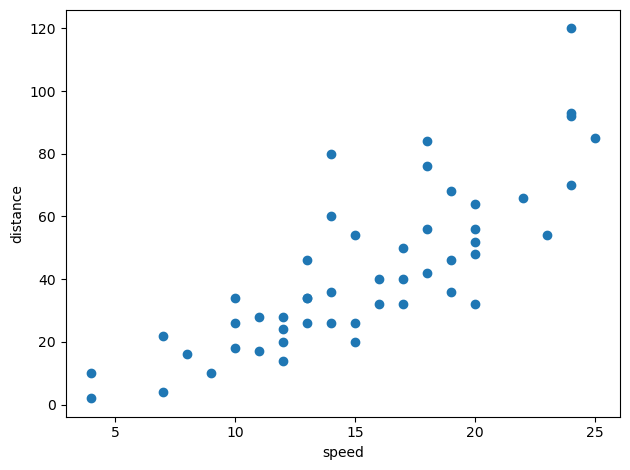

In [6]:
plt.scatter(df['speed'], df['dist'])
plt.xlabel('speed')
plt.ylabel('distance')
plt.tight_layout()
plt.show()

## Spliting the datasets

In [7]:
X = df[['speed']]
y = df['dist']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state= 42) 


### Fitting the data

In [9]:
lr = LinearRegression().fit(X_train, y_train)

In [10]:
print("intercept (b0):", lr.intercept_)
print("slope (b1 for speed):", lr.coef_[0])

intercept (b0): -14.133882307411156
slope (b1 for speed): 3.6856872567779666


In [11]:
# Evaluate
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test R²:", r2_score(y_test, y_pred))

NameError: name 'y_pred' is not defined

OLS slope: 3.6856872567779666
OLS intercept: -14.133882307411156
OLS Test RMSE: 16.596053231941138
OLS Test R²  : 0.6157734182280232


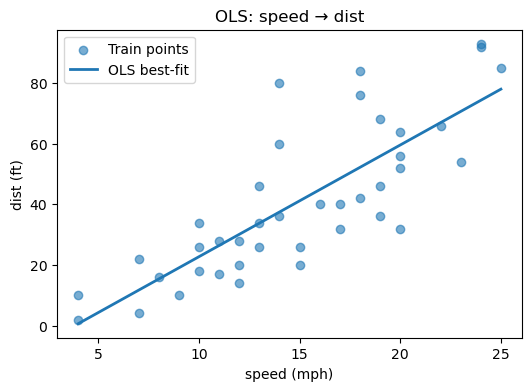

In [12]:
ols = LinearRegression().fit(X_train, y_train)

y_pred_test_ols = ols.predict(X_test)
print("OLS slope:", ols.coef_[0])
print("OLS intercept:", ols.intercept_)
print("OLS Test RMSE:", mean_squared_error(y_test, y_pred_test_ols, squared=False))
print("OLS Test R²  :", r2_score(y_test, y_pred_test_ols))

# visualize best-fit line on training data
plt.figure(figsize=(6,4))
plt.scatter(X_train['speed'], y_train, alpha=0.6, label='Train points')
x_line = np.linspace(X_train['speed'].min(), X_train['speed'].max(), 200).reshape(-1,1)
plt.plot(x_line, ols.predict(x_line), linewidth=2, label='OLS best-fit')
plt.xlabel('speed (mph)'); plt.ylabel('dist (ft)'); plt.title('OLS: speed → dist')
plt.legend(); plt.show()
